<h1 style="text-align:center; font-weight:bold; color: #db09bf;">
Model Architecture
</h1>

<hr style="width:50%; border:1px solid #db09bf; margin:auto;">


<h3 style="color: rgb(233, 150, 235); font-weight:bold;">
Data checking
</h3>


In [19]:
import os
import pandas as pd
from IPython.display import display

splits = ["train", "val", "test"]
SOURCE_PATH = "NN_Data_set"

data = {}

for split in splits:
    split_path = os.path.join(SOURCE_PATH, split)
    data[split] = {}

    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)

        if os.path.isdir(cls_path):
            data[split][cls] = len(os.listdir(cls_path))

df = pd.DataFrame(data).fillna(0).astype(int)
display(df)

,train,val,test
Battery,584,104,106
Cardboard,553,99,100
Clothes,547,97,99
Glass,614,101,103
Metal,613,101,102
Paper,567,101,102
Plastic,603,99,101


<div style="text-align:center;">

<h3 style="color:#db09bf; font-weight:bold; margin-bottom:5px;">
Custom CNN Architecture (From Scratch)
</h3>

<hr style="width:50%; border:1px solid #db09bf; margin:auto;">

</div>


In [20]:
import numpy as np
from pathlib import Path
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image_dataset_from_directory
from keras.applications import MobileNetV2

In [21]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [22]:
train_ds = image_dataset_from_directory(
    "NN_Data_set/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    "NN_Data_set/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = image_dataset_from_directory(
    "NN_Data_set/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 4081 files belonging to 7 classes.
Found 702 files belonging to 7 classes.
Found 713 files belonging to 7 classes.


In [23]:
class_names = train_ds.class_names
print(class_names)

['Battery', 'Cardboard', 'Clothes', 'Glass', 'Metal', 'Paper', 'Plastic']


<h3 style="color: rgb(233, 150, 235); font-weight:bold;">
✅ Normalization — Preprocessing Pipeline
</h3>

> MobileNetV2 was pretrained on ImageNet with pixel values in **[0, 1]**.
> Without normalization, the model receives values in [0, 255] which causes poor generalization and overfitting.


In [24]:
AUTOTUNE = tf.data.AUTOTUNE

# ── Normalize pixel values from [0, 255] → [0, 1] ──
# Applied to train, val, and test — NO augmentation (already done offline)
def preprocess(images, labels):
    images = tf.cast(images, tf.float32) / 255.0
    return images, labels

train_ds = train_ds.map(preprocess, num_parallel_calls=AUTOTUNE).shuffle(1000).cache().prefetch(AUTOTUNE)
val_ds   = val_ds.map(preprocess,   num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
test_ds  = test_ds.map(preprocess,  num_parallel_calls=AUTOTUNE)

print("Preprocessing pipeline ready ✓")

Preprocessing pipeline ready ✓


<div style="text-align:center; margin-top:40px;">

<h2 style="color:#db09bf; font-weight:bold;">
🔁 Transfer Learning — MobileNetV2
</h2>

<hr style="width:50%; border:2px solid #db09bf; margin:auto;">

<p style="color:#e996eb; font-size:14px; margin-top:8px;">
Using a pretrained MobileNetV2 backbone (ImageNet) with a custom classification head.
</p>

</div>


<div style="display:flex; gap:20px; align-items:flex-start; justify-content:center; margin-top:20px;">

<!-- Architecture box -->
<div style="
    display:inline-block;
    padding:10px 12px;
    border:3px solid #a730a1;
    border-radius:8px;
    background:#eba2f1;
    font-family:Arial;
    color:black;
    font-size:11px;
    line-height:1.2;
    font-weight:bold;
    width:300px;
">
Input Image (224×224×3)<br>↓<br>
Normalization (÷255)<br>↓<br>
MobileNetV2 backbone (frozen)<br>
&nbsp;&nbsp;<small>pretrained on ImageNet, include_top=False</small><br>↓<br>
GlobalAveragePooling2D<br>↓<br>
Dense (256, ReLU)<br>↓<br>
Dropout (0.5)<br>↓<br>
Dense (128, ReLU)<br>↓<br>
Dropout (0.3)<br>↓<br>
Output (Dense 7, Softmax)
<br><br>
<span style="color:#6a006a">── Fine-Tuning Phase ──</span><br>
Unfreeze last 30 layers<br>↓<br>
Recompile (LR = 1e-5)<br>↓<br>
Train again (20 epochs)
</div>

<!-- Phase description -->
<div style="
    padding:10px 14px;
    border:3px solid #a730a1;
    border-radius:8px;
    background:#f9e6fb;
    font-family:Arial;
    color:#3d003d;
    font-size:11.5px;
    line-height:1.6;
    width:340px;
">
<b>Phase 1 — Feature Extraction</b><br>
All MobileNetV2 layers frozen. Only the custom head is trained.<br><br>
<b>Phase 2 — Fine-Tuning</b><br>
Top 30 MobileNetV2 layers unfrozen and retrained with a very small learning rate (1e-5) to adapt to garbage classes without forgetting ImageNet knowledge.
<br><br>
<b>Key fixes vs previous version:</b><br>
• Added normalization (÷255)<br>
• Added extra Dense(128) + Dropout(0.3)<br>
• Reduced Dropout from 0.6 → 0.5<br>
• Increased fine-tune layers: 10 → 30<br>
• Reduced fine-tune LR: 1e-4 → 1e-5<br>
• Increased EarlyStopping patience: 3 → 7
</div>

</div>


<h3 style="color: rgb(233, 150, 235); font-weight:bold;">
Phase 1 — Feature Extraction (Frozen Base)
</h3>


In [25]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

NUM_CLASSES = len(class_names)
print(f"Number of classes: {NUM_CLASSES} → {class_names}")

Number of classes: 7 → ['Battery', 'Cardboard', 'Clothes', 'Glass', 'Metal', 'Paper', 'Plastic']


In [26]:
def build_mobilenet_model(num_classes, trainable_base=False):
    """
    Build a Transfer Learning model using MobileNetV2.
    Parameters
    num_classes   : int   — number of output classes
    trainable_base: bool  — whether to unfreeze the base model (fine-tuning)
    """
    # Load MobileNetV2 without the original top classifier
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,       # remove ImageNet head
        weights="imagenet"       # use pretrained ImageNet weights
    )

    base_model.trainable = trainable_base

    if trainable_base:
        # Fine-tuning: unfreeze only the last 30 layers (was 10)
        for layer in base_model.layers[:-30]:
            layer.trainable = False
        print(f"Fine-tuning mode — {sum(l.trainable for l in base_model.layers)} base layers trainable")
    else:
        print(f"Feature-extraction mode — all {len(base_model.layers)} base layers frozen")

    # Custom classification head
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.5)(x)                   
    x = Dense(128, activation="relu")(x)   # extra dense layer
    x = Dropout(0.3)(x)                    # extra dropout
    output = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=base_model.input, outputs=output)
    return model, base_model

In [27]:
# Build model — Phase 1 (frozen base)
MN_model, mn_base = build_mobilenet_model(NUM_CLASSES, trainable_base=False)

MN_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

MN_model.summary()

Feature-extraction mode — all 154 base layers frozen


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,619,719 (9.99 MB)

 Trainable params: 361,735 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [28]:
callbacks_mn_p1 = [
    EarlyStopping(
        monitor="val_loss",
        patience=7,              
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="best_mobilenet_phase1.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=4,              
        min_lr=1e-7,
        verbose=1
    )
]

In [29]:
print("Phase 1 — Feature Extraction (frozen base) …\n")

MN_history1 = MN_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks_mn_p1
)

print("\nPhase 1 complete")

Phase 1 — Feature Extraction (frozen base) …

Epoch 1/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.5394 - loss: 1.2916
Epoch 1: val_accuracy improved from None to 0.86895, saving model to best_mobilenet_phase1.keras

Epoch 1: finished saving model to best_mobilenet_phase1.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 57s 395ms/step - accuracy: 0.6827 - loss: 0.8857 - val_accuracy: 0.8689 - val_loss: 0.3595 - learning_rate: 0.0010
Epoch 2/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.8393 - loss: 0.4658
Epoch 2: val_accuracy improved from 0.86895 to 0.90171, saving model to best_mobilenet_phase1.keras

Epoch 2: finished saving model to best_mobilenet_phase1.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 45s 351ms/step - accuracy: 0.8520 - loss: 0.4337 - val_accuracy: 0.9017 - val_loss: 0.2949 - learning_rate: 0.0010
Epoch 3/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.8661 - loss: 0.3768
Epoch 3: val_accuracy did not improve from 0.90171
128/128 ━━━━━━━━━━━━━━━━━━━━

<h3 style="color: rgb(233, 150, 235); font-weight:bold;">
Phase 2 — Fine-Tuning (Unfreeze Last 30 Layers)
</h3>


In [30]:
# Unfreeze the top 30 layers of MobileNetV2 (was 10)
mn_base.trainable = True
for layer in mn_base.layers[:-30]:
    layer.trainable = False

trainable = sum(1 for l in mn_base.layers if l.trainable)
print(f"Fine-tuning: {trainable} base layers are now trainable")

# Reduced LR to 1e-5 avoid damaging pretrained weights
MN_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Fine-tuning: 30 base layers are now trainable


In [31]:
callbacks_mn_p2 = [
    EarlyStopping(
        monitor="val_loss",
        patience=7,              
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="best_mobilenet_phase2.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=4,
        min_lr=1e-8,
        verbose=1
    )
]

print("Phase 2 — Fine-Tuning …\n")

MN_history2 = MN_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,                   
    callbacks=callbacks_mn_p2
)

print("\nPhase 2 fine-tuning complete")

Phase 2 — Fine-Tuning …

Epoch 1/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.7935 - loss: 0.7869
Epoch 1: val_accuracy improved from None to 0.91453, saving model to best_mobilenet_phase2.keras

Epoch 1: finished saving model to best_mobilenet_phase2.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 66s 462ms/step - accuracy: 0.8282 - loss: 0.6023 - val_accuracy: 0.9145 - val_loss: 0.2671 - learning_rate: 1.0000e-05
Epoch 2/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.8778 - loss: 0.3606
Epoch 2: val_accuracy improved from 0.91453 to 0.91880, saving model to best_mobilenet_phase2.keras

Epoch 2: finished saving model to best_mobilenet_phase2.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 58s 452ms/step - accuracy: 0.8897 - loss: 0.3338 - val_accuracy: 0.9188 - val_loss: 0.2833 - learning_rate: 1.0000e-05
Epoch 3/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.9173 - loss: 0.2343
Epoch 3: val_accuracy improved from 0.91880 to 0.92023, saving model to best_mobilenet_phase

<h3 style="color: rgb(233, 150, 235); font-weight:bold;">
Evaluation — MobileNetV2
</h3>


In [32]:
mn_test_loss, mn_test_accuracy = MN_model.evaluate(test_ds)

print("\n")
print(f"Test Accuracy: {round(mn_test_accuracy * 100)}%")
print(f"Test Loss:     {mn_test_loss:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 308ms/step - accuracy: 0.9046 - loss: 0.3490


Test Accuracy: 90%
Test Loss:     0.3490


In [33]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

mn_y_true = []
mn_y_pred = []

for images, labels in test_ds:
    preds = MN_model.predict(images, verbose=0)
    mn_y_pred.extend(np.argmax(preds, axis=1))
    mn_y_true.extend(labels.numpy())

print(classification_report(mn_y_true, mn_y_pred, target_names=class_names))

              precision    recall  f1-score   support

     Battery       0.99      0.95      0.97       106
   Cardboard       0.92      0.86      0.89       100
     Clothes       0.97      1.00      0.99        99
       Glass       0.88      0.82      0.84       103
       Metal       0.82      0.91      0.87       102
       Paper       0.92      0.91      0.92       102
     Plastic       0.84      0.88      0.86       101

    accuracy                           0.90       713
   macro avg       0.91      0.90      0.90       713
weighted avg       0.91      0.90      0.90       713



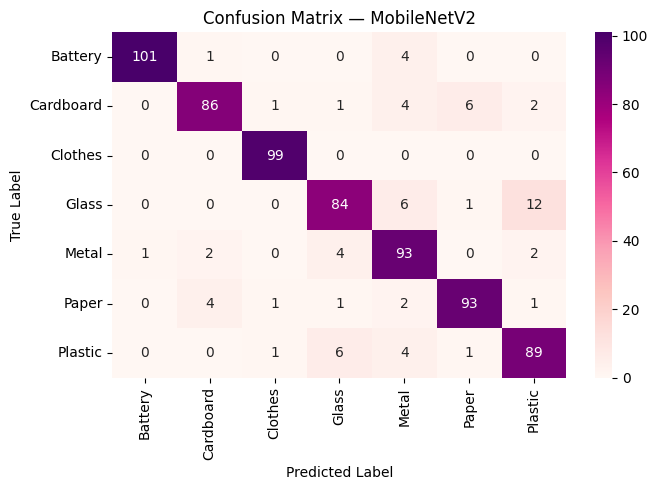

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

mn_cm = confusion_matrix(mn_y_true, mn_y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(mn_cm, annot=True, fmt='d', cmap='RdPu',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — MobileNetV2")
plt.tight_layout()
plt.show()

<h3 style="color: rgb(233, 150, 235); font-weight:bold;">
Learning Curves — MobileNetV2
</h3>


In [35]:
# Concatenate Phase 1 + Phase 2 history
mn_acc     = MN_history1.history['accuracy']     + MN_history2.history['accuracy']
mn_val_acc = MN_history1.history['val_accuracy'] + MN_history2.history['val_accuracy']
mn_loss    = MN_history1.history['loss']         + MN_history2.history['loss']
mn_val_loss= MN_history1.history['val_loss']     + MN_history2.history['val_loss']

mn_epochs       = range(1, len(mn_acc) + 1)
phase2_start    = len(MN_history1.history['accuracy']) + 1  # vertical divider

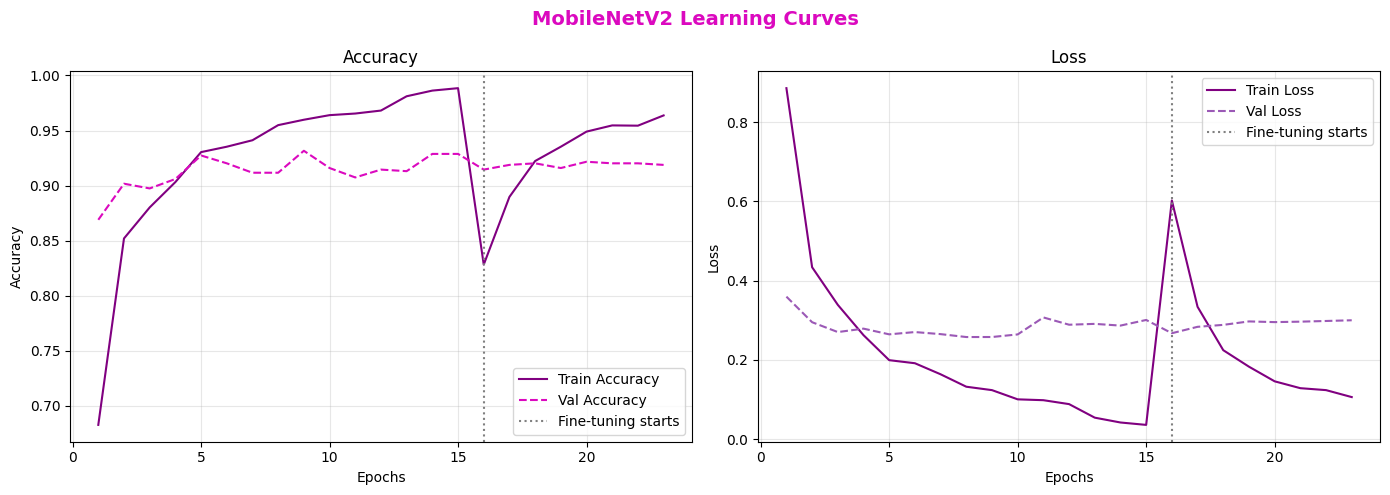

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("MobileNetV2 Learning Curves", fontsize=14, fontweight='bold', color='#db09bf')

# Accuracy
axes[0].plot(mn_epochs, mn_acc,     label='Train Accuracy',      color='purple')
axes[0].plot(mn_epochs, mn_val_acc, label='Val Accuracy',         color='#db09bf', linestyle='--')
axes[0].axvline(x=phase2_start, color='gray', linestyle=':', label='Fine-tuning starts')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(mn_epochs, mn_loss,     label='Train Loss',      color='purple')
axes[1].plot(mn_epochs, mn_val_loss, label='Val Loss',         color='#9b59b6', linestyle='--')
axes[1].axvline(x=phase2_start, color='gray', linestyle=':', label='Fine-tuning starts')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:

MN_model.save("mobilenet_v2_final.keras")
print("Model saved ✓")

import pickle
with open("mobilenet_v2_history.pkl", "wb") as f:
    pickle.dump({
        "phase1": MN_history1.history,
        "phase2": MN_history2.history
    }, f)
print("History saved ")

Model saved ✓
History saved 
